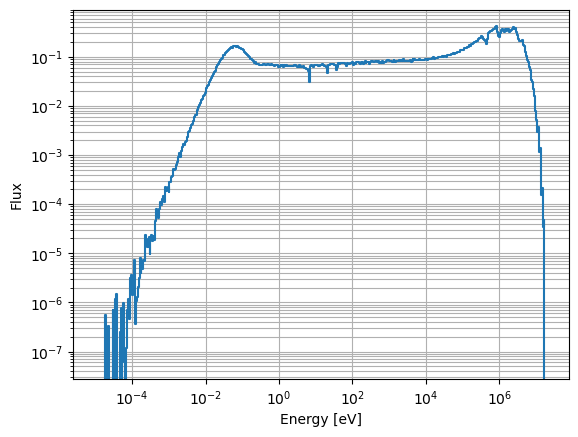

In [1]:
import matplotlib.pyplot as plt
import openmc

# Get results from statepoint
with openmc.StatePoint('statepoint.100.h5') as sp:
    t = sp.get_tally(name="Flux spectrum")

    # Get the energies from the energy filter
    energy_filter = t.filters[0]
    energies = energy_filter.bins[:, 0]

    # Get the flux values
    mean = t.get_values(value='mean').ravel()
    uncertainty = t.get_values(value='std_dev').ravel()

# Plot flux spectrum
fix, ax = plt.subplots()
ax.loglog(energies, mean, drawstyle='steps-post')
ax.set_xlabel('Energy [eV]')
ax.set_ylabel('Flux')
ax.grid(True, which='both')
plt.show()


{np.int32(1): Tally
	ID             =	1
	Name           =	Mesh tally
	Filters        =	EnergyFilter, MeshFilter
	Nuclides       =	total
	Scores         =	['flux']
	Estimator      =	tracklength
	Multiply dens. =	True}


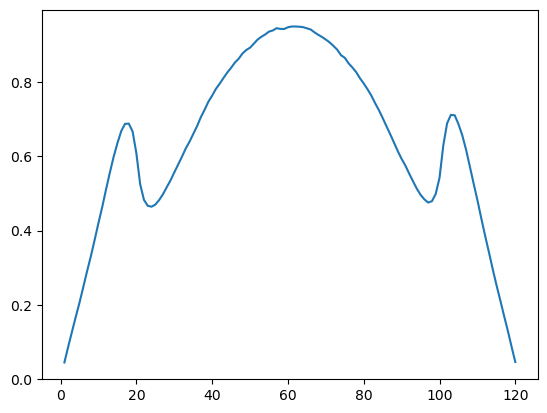

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import openmc

# Get results from statepoint
with openmc.StatePoint('2d_rect_sp.h5') as sp:
    tally = sp.tallies
    t = sp.get_tally(name="Mesh tally")

    # Get the energies from the energy filter
    mesh_filter = t.filters[1]
    mesh = mesh_filter.bins

    # Get the flux values
    mean = t.get_values(value='mean').ravel()
    stdev = t.get_values(value='std_dev').ravel()

print(tally)
mesh = np.array(mesh)
mean = 240.0 / np.sum(mean) * mean
flux_g2_omc = mean[:120]
flux_g1_omc = mean[120:]
stdev_g2_omc = stdev[:120]
stdev_g1_omc = stdev[120:]
plt.plot(mesh[:,0],flux_g2_omc)


(2, 240, 120, 1)


ValueError: x and y must have same first dimension, but have shapes (120,) and (240,)

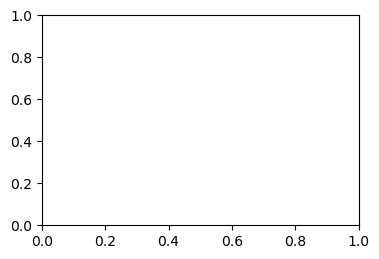

In [3]:
import numpy as np
import pickle

with open("2d_eig_rect_mt_mean.pkl", "rb") as f:   # 'rb' = read binary
    flux = pickle.load(f)

with open("2d_eig_rect_mt_stdev.pkl", "rb") as f:   # 'rb' = read binary
    std = pickle.load(f)

print(np.shape(flux))
flux = 240.0 / np.sum(flux) * flux
flux_g1 = flux[0,:,0,0]
flux_g2 = flux[1,:,0,0]
stdev_g1 = std[0,:,0,0]
stdev_g2 = std[1,:,0,0]
plt.figure(figsize=(9, 6))
plt.subplot(2,2,1)
plt.plot(mesh[:,0],flux_g2)
plt.plot(mesh[:,0],flux_g2_omc)
err = (flux_g2_omc - flux_g2) / flux_g2_omc * 100.

plt.subplot(2,2,2)
plt.plot(mesh[:,0],err)

plt.subplot(2,2,3)
plt.plot(mesh[:,0],stdev_g2)
plt.plot(mesh[:,0],stdev_g2_omc)



In [ ]:
import numpy as np
import pickle
import torch


with open("2d_eig_mt_mean.pkl", "rb") as f:   # 'rb' = read binary
    flux = pickle.load(f)

with open("2d_eig_mt_stdev.pkl", "rb") as f:   # 'rb' = read binary
    std = pickle.load(f)

print(flux.shape)
flux = np.prod(flux.shape) / np.sum(flux) * flux
flux1 = flux[0,:,:,0]
flux2 = flux[1,:,:,0]

with open("tt_2d_eig_mt_mean.pkl", "rb") as f:   # 'rb' = read binary
    flux_tt = pickle.load(f)

with open("tt_2d_eig_mt_stdev.pkl", "rb") as f:   # 'rb' = read binary
    std_tt = pickle.load(f)

print(flux_tt.shape)
flux_tt = flux_tt.numpy()
flux1_tt = flux_tt[0,:,:,0]
flux2_tt = flux_tt[1,:,:,0]
flux_tt = np.prod(flux_tt.shape) / np.sum(flux_tt) * flux_tt

error = (flux - flux_tt) / flux

print(np.linalg.norm(error)/np.prod(flux_tt.shape))
print(np.max(np.abs(error)))

(2, 120, 120, 1)
torch.Size([2, 120, 120, 1])
0.00030046494049687706
0.9086330553061414


In [ ]:
import numpy as np

a = np.random.random((3,4,2))
b = np.zeros_like(a)
b.fill(1)
c = np.zeros_like(a)
c.fill(2)
a.fill(0)

for x,y,z in zip(a.ravel(), b.ravel(), c.ravel()):
    z = x + y

for x,y,z in zip(a.ravel(), b.ravel(), c.ravel()):
    print(x, y, z)



0.0 1.0 2.0
0.0 1.0 2.0
0.0 1.0 2.0
0.0 1.0 2.0
0.0 1.0 2.0
0.0 1.0 2.0
0.0 1.0 2.0
0.0 1.0 2.0
0.0 1.0 2.0
0.0 1.0 2.0
0.0 1.0 2.0
0.0 1.0 2.0
0.0 1.0 2.0
0.0 1.0 2.0
0.0 1.0 2.0
0.0 1.0 2.0
0.0 1.0 2.0
0.0 1.0 2.0
0.0 1.0 2.0
0.0 1.0 2.0
0.0 1.0 2.0
0.0 1.0 2.0
0.0 1.0 2.0
0.0 1.0 2.0


{np.int32(1): Tally
	ID             =	1
	Name           =	Mesh tally
	Filters        =	EnergyFilter, MeshFilter
	Nuclides       =	total
	Scores         =	['flux']
	Estimator      =	tracklength
	Multiply dens. =	True}
[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100]


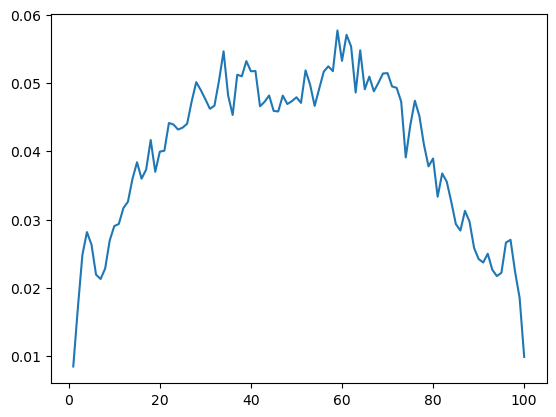

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import openmc

# Get results from statepoint
with openmc.StatePoint('1d_sp.h5') as sp:
    tally = sp.tallies
    t = sp.get_tally(name="Mesh tally")

    # Get the energies from the energy filter
    mesh_filter = t.filters[1]
    mesh = mesh_filter.bins

    # Get the flux values
    mean = t.get_values(value='mean').ravel()
    stdev = t.get_values(value='std_dev').ravel()

print(tally)
mesh = np.array(mesh)
mean = np.size(mean) / np.sum(mean) * mean
flux_g2_omc = mean[:100]
flux_g1_omc = mean[100:]
stdev_g2_omc = stdev[:100]
stdev_g1_omc = stdev[100:]
print(mesh[:,2])
# plt.plot(mesh[:,2],flux_g2_omc)

(2, 1, 1, 100)
45.09122390909301
45.015760509572736


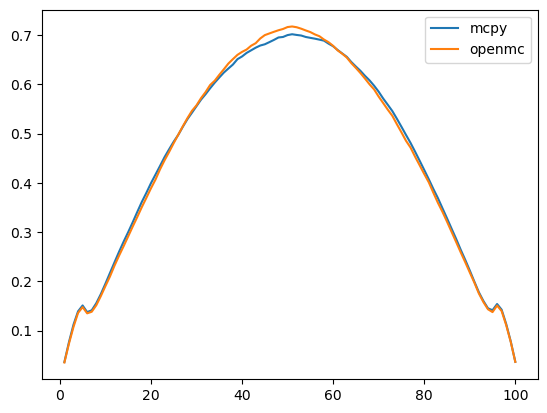

In [40]:
import pickle

with open("1d_mt.pkl", "rb") as f:   # 'rb' = read binary
    flux = pickle.load(f)

with open("1d_mt_stdev.pkl", "rb") as f:   # 'rb' = read binary
    std = pickle.load(f)

print(flux.shape)
flux = np.size(flux) / np.sum(flux) * flux
flux2 = flux[1,0,0,:]
std2 = std[1,0,0,:]*100
# plt.plot(mesh[:,2],std2)
plt.plot(mesh[:,2],flux2, label="mcpy")
plt.plot(mesh[:,2],flux_g2_omc, label="openmc")
plt.legend()
print(np.sum(flux2))
print(np.sum(flux_g2_omc))

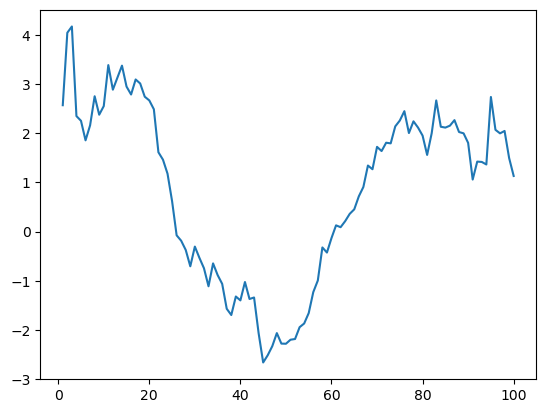

In [27]:
err = (flux2 - flux_g2_omc) / flux_g2_omc * 100
plt.plot(mesh[:,2],err)